# Lab 3: Spark k-means

*Autor: Adam Jakubowski 193352*

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

spark = SparkSession.builder.appName("Lab3").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

In [4]:
df = spark.read.text("data/3.txt")
df = df.selectExpr("split(value, ' ') as mycolumns")
df = df.select([df['mycolumns'][i].cast("float").alias(f'data_{i}') for i in range(58)])
df.show(10)

+------+------+------+------+------+------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|data_0|data_1|data_2|data_3|data_4|data_5|data_6|data_7|data_8|data_9|data_10|data_11|data_12|data_13|data_14|data_15|data_16|data_17|data_18|data_19|data_20|data_21|data_22|data_23|data_24|data_25|data_26|data_27|data_28|data_29|data_30|data_31|data_32|data_33|data_34|data_35|data_36|data_37|data_38|data_39|data_40|data_41|data_42|data_43|data_44|data_45|data_46|data_47|data_48|data_49|data_50|data_51|data_52|data_53|data_54|data_55|data_56|data_57|
+------+------+------+------+------+------+------+------+------+------+-------+-------+-

In [5]:
vecAssembler = VectorAssembler(inputCols=df.columns, outputCol="features")
df_kmeans = vecAssembler.transform(df)
df_kmeans.select("features").show(10, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                                                                                                                                           

Total time: 2.4122 s
Silhouette score: 0.7693
+--------------------+----------+
|            features|prediction|
+--------------------+----------+
|(58,[1,2,4,11,15,...|         8|
|(58,[0,1,2,4,5,6,...|         9|
|(58,[0,2,4,5,6,7,...|         2|
|(58,[4,6,7,8,9,10...|         8|
|(58,[4,6,7,8,9,10...|         8|
+--------------------+----------+
only showing top 5 rows


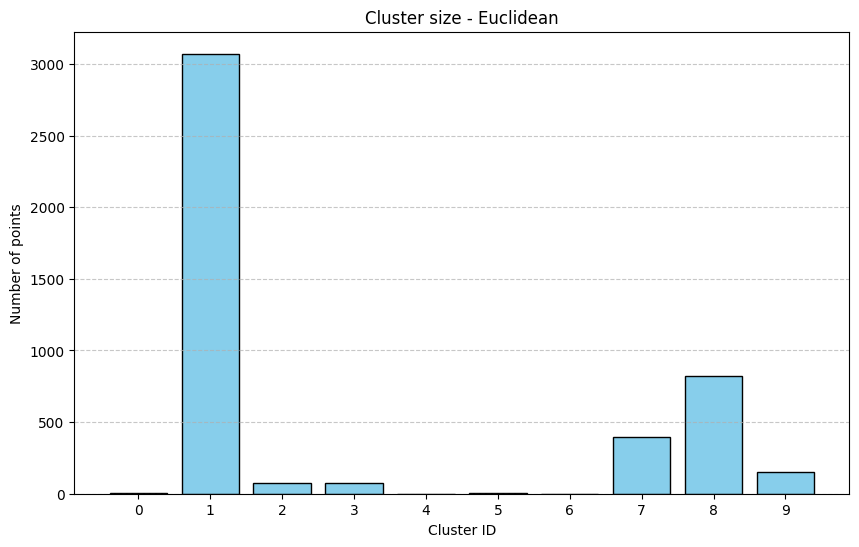

In [12]:
kmeans_euclidean = KMeans(featuresCol="features", predictionCol="prediction", k=10, distanceMeasure="euclidean", seed=42)
start_time_euclidean = time.time()
model_euclidean = kmeans_euclidean.fit(df_kmeans)
end_time_euclidean = time.time()

predictions_euclidean = model_euclidean.transform(df_kmeans)
evaluator_euclidean = ClusteringEvaluator(predictionCol="prediction", featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")
silhouette_score_euclidean = evaluator_euclidean.evaluate(predictions_euclidean)

total_time_euclidean = end_time_euclidean - start_time_euclidean
print(f"Total time: {total_time_euclidean:.4f} s")
print(f"Silhouette score: {silhouette_score_euclidean:.4f}")

predictions_euclidean.select("features", "prediction").show(5)

cluster_counts_euclidean = predictions_euclidean.groupBy("prediction").count().orderBy("prediction").toPandas()

plt.figure(figsize=(10, 6))
plt.bar(cluster_counts_euclidean["prediction"], cluster_counts_euclidean["count"], color='skyblue', edgecolor='black')
plt.title("Cluster size - Euclidean")
plt.xlabel("Cluster ID")
plt.ylabel("Number of points")
plt.xticks(range(10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Total time: 2.9876 s
Silhouette score: 0.1519
+--------------------+----------+
|            features|prediction|
+--------------------+----------+
|(58,[1,2,4,11,15,...|         2|
|(58,[0,1,2,4,5,6,...|         8|
|(58,[0,2,4,5,6,7,...|         2|
|(58,[4,6,7,8,9,10...|         2|
|(58,[4,6,7,8,9,10...|         2|
+--------------------+----------+
only showing top 5 rows


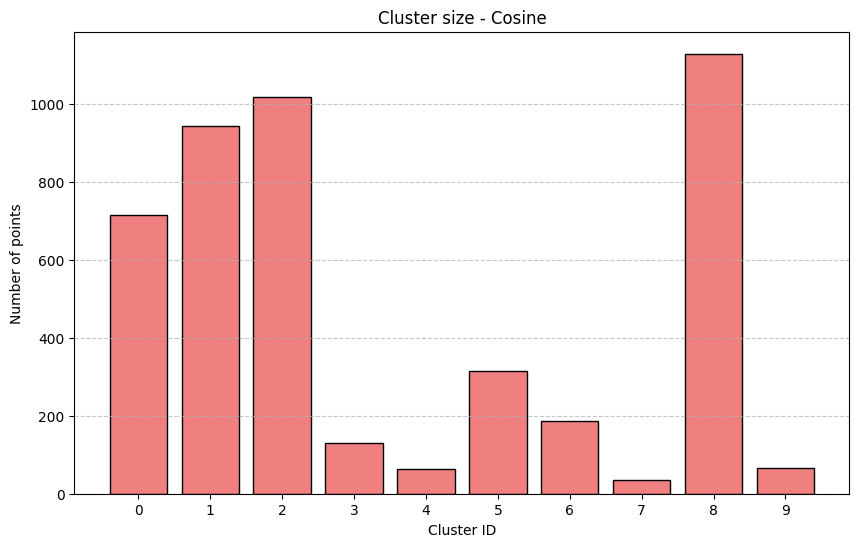

In [13]:
kmeans_cosine = KMeans(featuresCol="features", predictionCol="prediction", k=10, distanceMeasure="cosine", seed=42)

start_time_cosine = time.time()
model_cosine = kmeans_cosine.fit(df_kmeans)
end_time_cosine = time.time()

predictions_cosine = model_cosine.transform(df_kmeans)
evaluator_cosine = ClusteringEvaluator(predictionCol="prediction", featuresCol="features", metricName="silhouette", distanceMeasure="cosine")
silhouette_score_cosine = evaluator_cosine.evaluate(predictions_cosine)

time_cosine = end_time_cosine - start_time_cosine
print(f"Total time: {time_cosine:.4f} s")
print(f"Silhouette score: {silhouette_score_cosine:.4f}")

predictions_cosine.select("features", "prediction").show(5)

cluster_counts_cosine = predictions_cosine.groupBy("prediction").count().orderBy("prediction").toPandas()

plt.figure(figsize=(10, 6))
plt.bar(cluster_counts_cosine["prediction"], cluster_counts_cosine["count"], color='lightcoral', edgecolor='black')
plt.title("Cluster size - Cosine")
plt.xlabel("Cluster ID")
plt.ylabel("Number of points")
plt.xticks(range(10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
spark.stop()

# Summary

The Euclidean distance achieved a high Silhouette score, but it put almost all data points into one giant cluster, which is not very practical. In contrast, the Cosine distance had a lower score, but it distributed the data much more evenly across different clusters.

# Conclusion
Even though the Euclidean distance had a better mathematical score, the Cosine distance did a much better job of creating balanced and meaningful groups. This happens because Euclidean distance is very sensitive to the size of the vectors (unscaled data), while Cosine distance only looks at the angle between them.